In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
zip_path = "/content/drive/MyDrive/Food recognition/Food_detection_and_health_care.v2i.yolov8.zip"
output_path = "/content/dataset"

# Unzip the dataset
!unzip -q "$zip_path" -d "$output_path"

In [ ]:
# Check dataset structure
!ls "$output_path"

In [ ]:
pip install ultralytics

In [ ]:
from ultralytics import YOLO

# Load YOLOv8 model
model = YOLO("yolov8s.pt")

# Train the model
model.train(
    #data="/media/mtl/DATA 6TB/PROJECT AI/Vietnamese-Food-Detection-with-YOLOv8-and-AndroidApp/dataset.v2i.yolov8./data.yaml"
    data="dataset/data.yaml",  # Path to the YAML file
    epochs=70,  # Number of epochs
    imgsz=640,  # Image size
    project="runs",  # Folder to save results
    name="food_detection" # Model name
)

In [ ]:
import shutil
import os

# Create a folder in Google Drive to save the model
save_dir = "yolo_models"
os.makedirs(save_dir, exist_ok=True)

# Copy the best model (best.pt) to Google Drive
source_path = "runs/food_detection/weights/best.pt"
destination_path = os.path.join(save_dir, "food_detection_best.pt")
shutil.copy(source_path, destination_path)

# Copy the last model (last.pt) to Google Drive
source_path_last = "runs/food_detection/weights/last.pt"
destination_path_last = os.path.join(save_dir, "food_detection_last.pt")
shutil.copy(source_path_last, destination_path_last)

print(f"Model đã được lưu tại:\n- {destination_path}\n- {destination_path_last}")

In [1]:
from ultralytics import YOLO

# Load the model from Google Drive
model_path = "yolo_models/food_detection_best.pt"
model = YOLO(model_path)


Found https://img-global.cpcdn.com/recipes/2c630c584ca9709c/680x482cq70/bun-dậu-mắm-tom-recipe-main-photo.jpg locally at bun-dậu-mắm-tom-recipe-main-photo.jpg
image 1/1 /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/yolo/bun-dậu-mắm-tom-recipe-main-photo.jpg: 480x640 1 bun, 1 bun dau, 1 cha com, 5 dau hus, 2 thit heos, 38.4ms
Speed: 3.2ms preprocess, 38.4ms inference, 5.6ms postprocess per image at shape (1, 3, 480, 640)


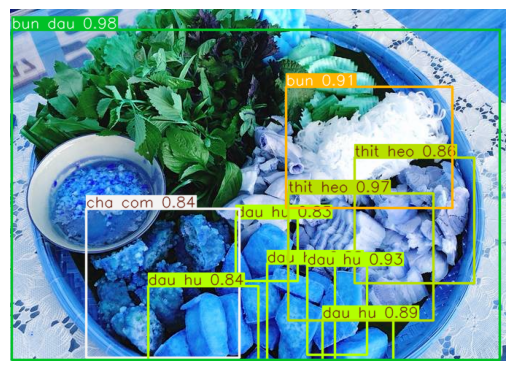

In [2]:
import matplotlib.pyplot as plt

# Perform predictions on an image
results = model.predict(
    source='https://img-global.cpcdn.com/recipes/2c630c584ca9709c/680x482cq70/bun-d%E1%BA%ADu-m%E1%BA%AFm-tom-recipe-main-photo.jpg',
    conf=0.5  # Confidence threshold
)

# Get the image with bounding boxes annotated
annotated_image = results[0].plot()

# Display the image in Google Colab
plt.imshow(annotated_image)
plt.axis('off')  # Turn off axis display
plt.show()

In [ ]:
# Perform predictions on an image
results = model.predict(
    source='https://i2.ex-cdn.com/crystalbay.com/files/content/2024/08/15/bun-bo-hue-2-0933.jpg',
    conf=0.5  # Confidence threshold
)

# Get the image with bounding boxes annotated
annotated_image = results[0].plot()

# Display the image in Google Colab
plt.imshow(annotated_image)
plt.axis('off')  # Turn off axis display
plt.show()

In [ ]:
# Perform predictions on an image
results = model.predict(
    source='https://static.hawonkoo.vn/hwk02/images/2023/10/com-tam-suon-bi-cha-2.jpg',
    conf=0.5  # Confidence threshold
)

# Get the image with bounding boxes annotated
annotated_image = results[0].plot()

# Display the image in Google Colab
plt.imshow(annotated_image)
plt.axis('off')  # Turn off axis display
plt.show()

In [ ]:
# Get the list of classes
class_names = model.names
print("List of classes in the YOLO model:")
for i, name in class_names.items():
    print(f"{i}: {name}")